In [ ]:
from transformers import AutoImageProcessor, ViTForImageClassification
import torch
from PIL import Image
import sys
from pathlib import Path
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))


In [ ]:
from tokenfool.attacks import PatchFool
from tokenfool.adapters import HuggingFaceViTAdapter

Initialize DeiT model

In [3]:
model_name = "google/vit-base-patch16-224"

vit = ViTForImageClassification.from_pretrained(model_name).eval().to(device)

processor = AutoImageProcessor.from_pretrained(model_name, use_fast=True)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Initial image and prediction

Predicted class: 4
hammerhead, hammerhead shark


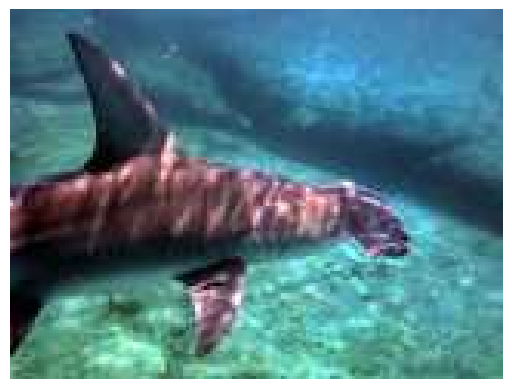

In [4]:
image_path = Path("test_data/ILSVRC2012_val_00021325.JPEG")
raw_image = Image.open(image_path).convert("RGB")
raw_size = raw_image.size
plt.imshow(raw_image)
plt.axis("off")


img = processor(images=raw_image, return_tensors="pt")

with torch.no_grad():
    outputs = vit(**img)
    pred_class = outputs.logits.argmax(dim=1).item()

print(f"Predicted class: {pred_class}")
print(vit.config.id2label[pred_class])

In [46]:
tokenfool_model = HuggingFaceViTAdapter(vit)

Attack - default parameters

In [48]:

x_adv, mask = PatchFool(model=tokenfool_model, x=img["pixel_values"], iters=100, progress=True)

PatchFool:   0%|          | 0/100 [00:00<?, ?it/s]

Attacked image and prediction

Adversarial class: 3
tiger shark, Galeocerdo cuvieri


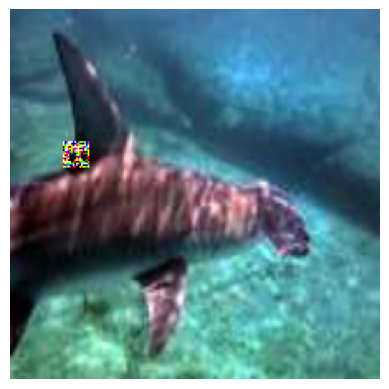

In [49]:
img_adv = x_adv[0].detach().cpu()


mean = torch.tensor(processor.image_mean).view(3, 1, 1)
std = torch.tensor(processor.image_std).view(3, 1, 1)

img_adv = img_adv * std + mean
plt.imshow(img_adv.permute(1,2,0).clamp(0,1))
plt.axis("off")

with torch.no_grad():
    pred_adv = vit(x_adv)
    pred_adv_class = pred_adv.logits.argmax(dim=1).item()

print(f"Adversarial class: {pred_adv_class}")
print(vit.config.id2label[pred_adv_class])

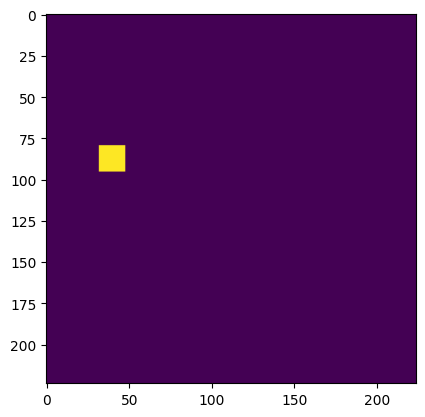

In [50]:
mask = mask[0].detach().cpu()
mask = mask.permute(1,2,0)
plt.imshow(mask)